In [2]:
# Task 2 (Riley)

import pandas as pd

df = pd.read_csv("ardd_fatalities.csv")

print("Number of records:", df.shape[0])
print("Number of features/columns:", df.shape[1])

Number of records: 55360
Number of features/columns: 24


C:\Users\AwesomeUser\AppData\Local\Temp\ipykernel_24492\865952067.py:5: DtypeWarning: Columns (0: Speed Limit, 1: National Remoteness Areas, 2: SA4 Name 2021, 3: National LGA Name 2021, 4: National Road Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ardd_fatalities.csv")


In [3]:
# Save the DataFrame to a CSV file in your current folder
df.to_csv("fatalities.csv", index=False)

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Current Directory:", os.getcwd())
print("Files in folder:", os.listdir())

df = pd.read_csv("ardd_fatalities.csv")
print("Initial shape:", df.shape)

df.columns = df.columns.str.strip()
print("Cleaned Column Names:", df.columns.tolist())

Current Directory: c:\Users\AwesomeUser\.venv\ENGE707_WizardsofOdds
Files in folder: ['.git', 'ardd_fatalities.csv', 'ardd_fatalities_cleaned.csv', 'CrashDataSet.csv', 'CrashDataset.ipynb', 'fatalities.csv', 'fatalities.ipynb', 'README.md']
Initial shape: (55360, 24)
Cleaned Column Names: ['Crash ID', 'State', 'Month', 'Year', 'Dayweek', 'Time', 'Crash Type', 'Bus Involvement', 'Heavy Rigid Truck Involvement', 'Articulated Truck Involvement', 'Speed Limit', 'Road User', 'Gender', 'Age', 'National Remoteness Areas', 'SA4 Name 2021', 'National LGA Name 2021', 'National Road Type', 'Christmas Period', 'Easter Period', 'Age Group', 'Day of week', 'Time of day', 'Unnamed: 23']


C:\Users\AwesomeUser\AppData\Local\Temp\ipykernel_22364\1090256368.py:10: DtypeWarning: Columns (0: Speed Limit, 1: National Remoteness Areas, 2: SA4 Name 2021, 3: National LGA Name 2021, 4: National Road Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ardd_fatalities.csv")


In [2]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate records.")

string_cols = df.select_dtypes(include=["object"]).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

if "State" in df.columns:
    state_mapping = {
        "Nsw": "NSW",
        "Vic": "VIC",
        "Qld": "QLD",
        "Wa": "WA",
        "Sa": "SA",
        "Tas": "TAS",
        "Act": "ACT",
        "Nt": "NT",
    }
    df["State"] = df["State"].replace(state_mapping)

Removed 168 duplicate records.


C:\Users\AwesomeUser\AppData\Local\Temp\ipykernel_22364\509318881.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=["object"]).columns


In [3]:
date_columns = [col for col in df.columns if "Date" in col or "date" in col]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

if "Crash Speed Limit" in df.columns:
    df["Crash Speed Limit"] = pd.to_numeric(
        df["Crash Speed Limit"], errors="coerce"
    )

if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

aus_geo_cols = [
    col
    for col in ["SA4 Name 2021", "National LGA Name 2021"]
    if col in df.columns
]
for col in aus_geo_cols:
    if "Country" in df.columns:
        df.loc[
            (df["Country"] == "New Zealand") & (df[col].isna()), col
        ] = "Not Applicable (NZ)"

if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

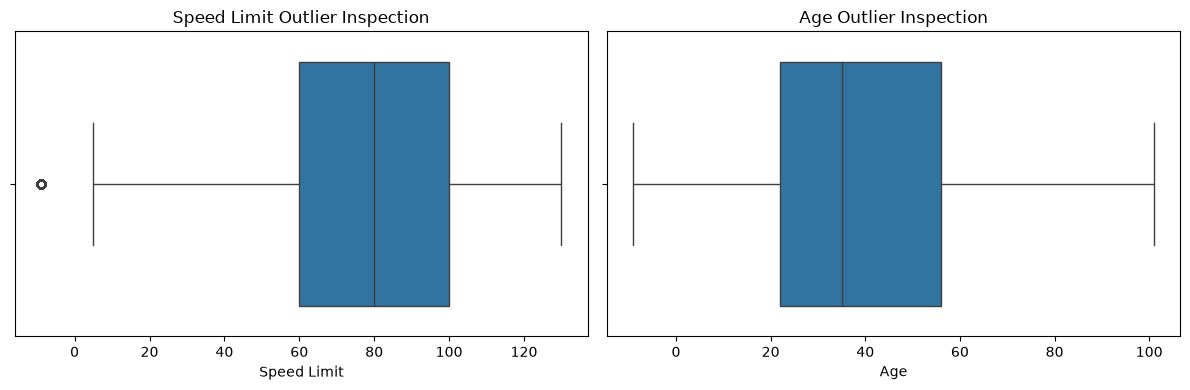

In [5]:
speed_col = [col for col in df.columns if "Speed" in col or "speed" in col]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if speed_col:
    col_name = speed_col[0]

    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")

    sns.boxplot(ax=axes[0], x=df[col_name]).set(
        title=f"{col_name} Outlier Inspection"
    )

    df.loc[(df[col_name] > 130) | (df[col_name] < 5), col_name] = np.nan
else:
    axes[0].set_title("Speed Limit Column Not Found")

if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    sns.boxplot(ax=axes[1], x=df["Age"]).set(title="Age Outlier Inspection")

plt.tight_layout()
plt.show()

In [6]:
date_col = date_columns[0] if date_columns else None
if date_col and date_col in df.columns:
    df["Year"] = df[date_col].dt.year
    df["Month"] = df[date_col].dt.month
    df["DayOfWeek"] = df[date_col].dt.day_name()

categorical_cols = df.select_dtypes(include=["object"]).columns
df_encoded = pd.get_dummies(
    df, columns=categorical_cols, drop_first=True, dummy_na=False
)

df.to_csv("ardd_fatalities_cleaned.csv", index=False)
print(
    "Data cleansing complete. Cleaned dataset saved as 'ardd_fatalities_cleaned.csv'."
)

C:\Users\AwesomeUser\AppData\Local\Temp\ipykernel_22364\2274052830.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


Data cleansing complete. Cleaned dataset saved as 'ardd_fatalities_cleaned.csv'.
